In [1]:
import pandas as pd

In [2]:
file_path = "/content/Zomata - Copy.xlsx"
xls = pd.ExcelFile(file_path)

In [3]:
fact_main = pd.read_excel(xls, sheet_name="Main")
dim_country = pd.read_excel(xls, sheet_name="Country")
dim_calendar = pd.read_excel(xls, sheet_name="Calendar")
dim_currency = pd.read_excel(xls, sheet_name="Currency")

In [5]:
fact_main = fact_main.merge(dim_country,how="left",left_on="CountryCode", right_on="CountryID")

In [7]:
fact_main = fact_main.merge(dim_calendar,how="left",left_on="Datekey_Opening",right_on="Datekey_Opening")

In [8]:
fact_main = fact_main.merge(dim_currency,how="left",on="Currency")

In [9]:
fact_main.head()

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,...,Year,MonthNo,MonthName,Quarter,YearMonth,WeekdayNo,WeekdayName,FinancialMonth,FinancialQuarter,USD Rate
0,18435314,Punjabi's Veg Grill,1,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,North Indian,...,2013,9,September,Q3,Sep-2013,6,Saturday,FM-6,FQ-2,0.012
1,18378015,Tasty Tandoor,1,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,North Indian,...,2016,9,September,Q3,Sep-2016,6,Saturday,FM-6,FQ-2,0.012
2,18424905,Taste of Spice,1,New Delhi,"C-222, Lajpat Nagar 1, New Delhi",Lajpat Nagar 1,"Lajpat Nagar 1, New Delhi",77.241312,28.578311,North Indian,...,2018,9,September,Q3,Sep-2018,2,Tuesday,FM-6,FQ-2,0.012
3,18180072,Kolcata Bengali Dhaba,1,New Delhi,"Gali 7, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.123932,28.543587,North Indian,...,2018,9,September,Q3,Sep-2018,4,Thursday,FM-6,FQ-2,0.012
4,18415377,Sunil Punjabi Dhaba,1,New Delhi,"Main Vasant Kunj Road, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.129706,28.541369,North Indian,...,2013,9,September,Q3,Sep-2013,2,Tuesday,FM-6,FQ-2,0.012


In [10]:
dim_currency.head()

,Currency,USD Rate
0,Indian Rupees(Rs.),0.012
1,Dollar($),1.000
2,Pounds(Œ£),1.240
3,NewZealand($),0.600
4,Emirati Diram(AED),0.270


In [11]:
merged_df = fact_main.merge(dim_currency,how="left",on="Currency")

In [14]:
merged_df.columns

Index(['RestaurantID', 'RestaurantName', 'CountryCode', 'City', 'Address',
       'Locality', 'LocalityVerbose', 'Longitude', 'Latitude', 'Cuisines',
       'Currency', 'Has_Table_booking', 'Has_Online_delivery',
       'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Votes',
       'Average_Cost_for_two', 'Rating', 'Year Opening', 'Month Opening',
       'Day Opening', 'Date_x', 'Datekey_Opening', 'CountryID', 'Countryname',
       'Date_y', 'Year', 'MonthNo', 'MonthName', 'Quarter', 'YearMonth',
       'WeekdayNo', 'WeekdayName', 'FinancialMonth', 'FinancialQuarter',
       'USD Rate_x', 'USD Rate_y'],
      dtype='object')

In [16]:
merged_df["Average_Cost_for_two_USD"] = merged_df["Average_Cost_for_two"] * merged_df["USD Rate_y"]
merged_df[["RestaurantName", "Currency", "Average_Cost_for_two", "USD Rate_y", "Average_Cost_for_two_USD"]].head()

,RestaurantName,Currency,Average_Cost_for_two,USD Rate_y,Average_Cost_for_two_USD
0,Punjabi's Veg Grill,Indian Rupees(Rs.),300,0.012,3.6
1,Tasty Tandoor,Indian Rupees(Rs.),200,0.012,2.4
2,Taste of Spice,Indian Rupees(Rs.),400,0.012,4.8
3,Kolcata Bengali Dhaba,Indian Rupees(Rs.),100,0.012,1.2
4,Sunil Punjabi Dhaba,Indian Rupees(Rs.),150,0.012,1.8


In [17]:
final_df = merged_df.copy()
final_df["Average_Cost_for_two_USD"] = final_df["Average_Cost_for_two_USD"].round(2)

In [18]:
final_df = final_df.dropna(subset=["Average_Cost_for_two_USD"])

In [21]:
restaurants_by_city_country = (final_df.groupby(["Countryname", "City"]).agg(Restaurant_Count=("RestaurantID", "count")).reset_index().sort_values("Restaurant_Count", ascending=False))

In [22]:
restaurants_by_city_country.head(10)

,Countryname,City,Restaurant_Count
61,India,New Delhi,5473
45,India,Gurgaon,1118
62,India,Noida,1080
42,India,Faridabad,251
43,India,Ghaziabad,25
31,India,Ahmedabad,21
33,India,Amritsar,21
37,India,Bhubaneshwar,21
46,India,Guwahati,21
53,India,Lucknow,21


from matplotlib import pyplot as plt
_df_0['Restaurant_Count'].plot(kind='hist', bins=20, title='Restaurant_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Restaurant_Count'].plot(kind='line', figsize=(8, 4), title='Restaurant_Count')
plt.gca().spines[['top', 'right']].set_visible(False)

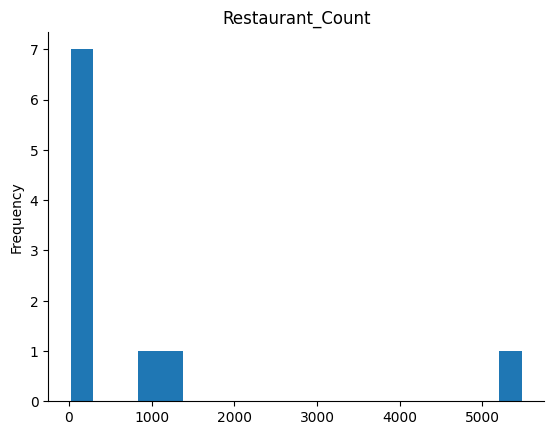

In [23]:
from matplotlib import pyplot as plt
_df_0['Restaurant_Count'].plot(kind='hist', bins=20, title='Restaurant_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [25]:
top_cities = (
    final_df.groupby("City")
      .agg(Restaurant_Count=("RestaurantID", "count"))
      .reset_index()
      .sort_values("Restaurant_Count", ascending=False)
      .head(10)
)

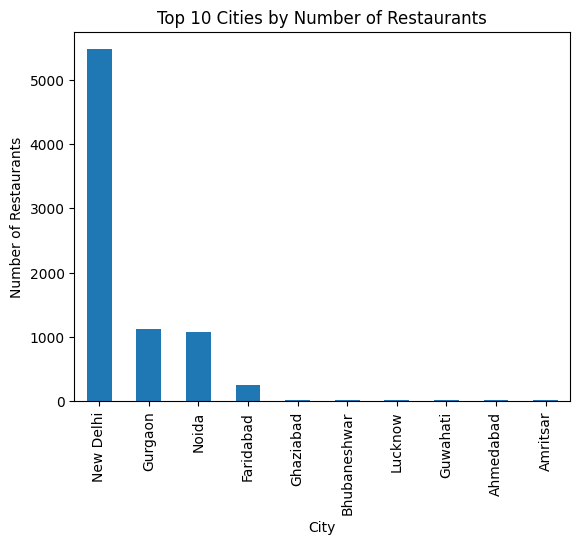

In [26]:
import matplotlib.pyplot as plt

top_cities.plot(
    x="City",
    y="Restaurant_Count",
    kind="bar",
    legend=False,
    title="Top 10 Cities by Number of Restaurants"
)
plt.ylabel("Number of Restaurants")
plt.show()


In [28]:
restaurants_by_year = (
    final_df.groupby("Year")
      .agg(Restaurant_Count=("RestaurantID", "count"))
      .reset_index()
      .sort_values("Year")
)

In [30]:
restaurants_by_quarter = (
    final_df.groupby(["Year", "Quarter"])
      .agg(Restaurant_Count=("RestaurantID", "count"))
      .reset_index()
      .sort_values(["Year", "Quarter"])
)

In [32]:
restaurants_by_month = (
    final_df.groupby(["Year", "MonthName"])
      .agg(Restaurant_Count=("RestaurantID", "count"))
      .reset_index()
)

In [34]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

restaurants_by_month["MonthName"] = pd.Categorical(
    restaurants_by_month["MonthName"],
    categories=month_order,
    ordered=True
)

restaurants_by_month = restaurants_by_month.sort_values(["Year", "MonthName"]) # Sort by MonthName after converting to categorical

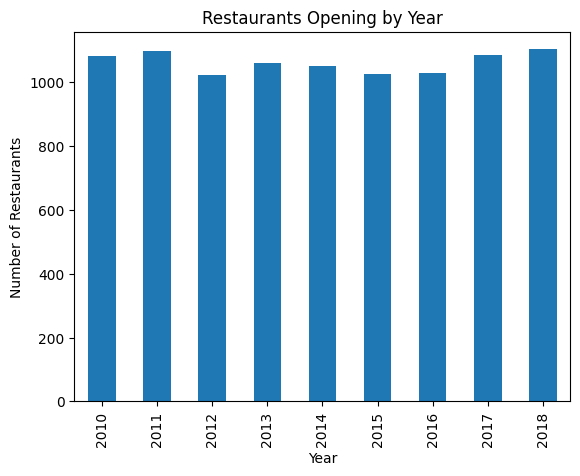

In [35]:
import matplotlib.pyplot as plt

restaurants_by_year.plot(
    x="Year",
    y="Restaurant_Count",
    kind="bar",
    title="Restaurants Opening by Year",
    legend=False
)
plt.ylabel("Number of Restaurants")
plt.show()

In [38]:
ratings_df = fact_main[
    (fact_main["Rating"].notna()) &
    (fact_main["Rating"] > 0)
]

In [40]:
restaurants_by_rating = (
    ratings_df
    .groupby("Rating")
    .agg(Restaurant_Count=("RestaurantID", "count"))
    .reset_index()
    .sort_values("Rating")
)

In [41]:
restaurants_by_rating.head(10)

,Rating,Restaurant_Count
0,1.0,2148
1,1.8,1
2,1.9,2
3,2.0,7
4,2.1,15
5,2.2,27
6,2.3,47
7,2.4,87
8,2.5,110
9,2.6,191


from matplotlib import pyplot as plt
_df_2['Rating'].plot(kind='hist', bins=20, title='Rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Restaurant_Count'].plot(kind='hist', bins=20, title='Restaurant_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='Rating', y='Restaurant_Count', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Rating']
  ys = series['Restaurant_Count']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_5.sort_values('Rating', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Rating')
_ = plt.ylabel('Restaurant_Count')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Rating']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Rating'}, axis=1)
              .sort_values('Rating', ascending=True))
  xs = counted['Rating']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_6.sort_values('Rating', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Rating')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_7['Rating'].plot(kind='line', figsize=(8, 4), title='Rating')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['Restaurant_Count'].plot(kind='line', figsize=(8, 4), title='Restaurant_Count')
plt.gca().spines[['top', 'right']].set_visible(False)

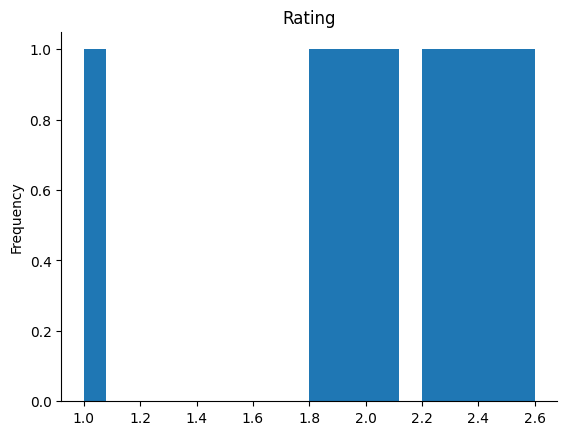

In [42]:
from matplotlib import pyplot as plt
_df_2['Rating'].plot(kind='hist', bins=20, title='Rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [44]:
bins = [0, 2, 3, 4, 5]
labels = ["Poor", "Average", "Good", "Excellent"]

ratings_df["Rating_Bucket"] = pd.cut(
    ratings_df["Rating"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rating_bucket_count = (
    ratings_df
    .groupby("Rating_Bucket")
    .agg(Restaurant_Count=("RestaurantID", "count"))
    .reset_index()
)

/tmp/ipython-input-1367000206.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Rating_Bucket")


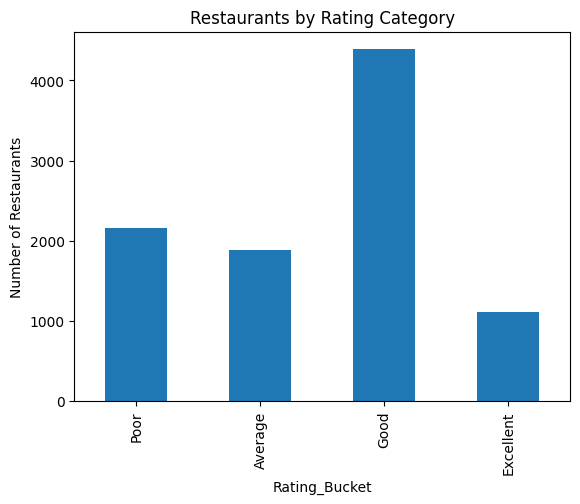

In [45]:
import matplotlib.pyplot as plt

rating_bucket_count.plot(
    x="Rating_Bucket",
    y="Restaurant_Count",
    kind="bar",
    legend=False,
    title="Restaurants by Rating Category"
)
plt.ylabel("Number of Restaurants")
plt.show()

In [47]:
price_df = final_df[
    (final_df["Average_Cost_for_two_USD"].notna()) &
    (final_df["Average_Cost_for_two_USD"] > 0)
]

In [49]:
bins = [0, 10, 30, 60, 100, price_df["Average_Cost_for_two_USD"].max()]
labels = ["Budget", "Affordable", "Mid-Range", "Premium", "Luxury"]

price_df["Price_Bucket"] = pd.cut(
    price_df["Average_Cost_for_two_USD"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

/tmp/ipython-input-819004987.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df["Price_Bucket"] = pd.cut(


In [51]:
price_bucket_count = (
    price_df
    .groupby("Price_Bucket")
    .agg(Restaurant_Count=("RestaurantID", "count"))
    .reset_index()
)

/tmp/ipython-input-3595916133.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Price_Bucket")


In [52]:
price_bucket_count

,Price_Bucket,Restaurant_Count
0,Budget,7255
1,Affordable,1817
2,Mid-Range,339
3,Premium,85
4,Luxury,37


from matplotlib import pyplot as plt
price_bucket_count['Restaurant_Count'].plot(kind='hist', bins=20, title='Restaurant_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
price_bucket_count['Restaurant_Count'].plot(kind='line', figsize=(8, 4), title='Restaurant_Count')
plt.gca().spines[['top', 'right']].set_visible(False)

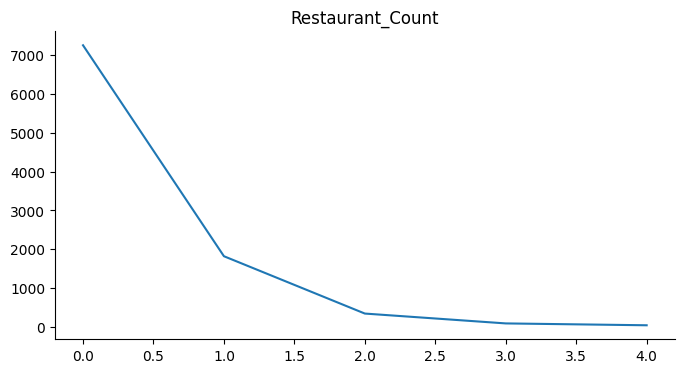

In [53]:
from matplotlib import pyplot as plt
price_bucket_count['Restaurant_Count'].plot(kind='line', figsize=(8, 4), title='Restaurant_Count')
plt.gca().spines[['top', 'right']].set_visible(False)

In [55]:
price_df["Dynamic_Price_Bucket"] = pd.qcut(
    price_df["Average_Cost_for_two_USD"],
    q=5,
    labels=["Very Cheap", "Cheap", "Moderate", "Expensive", "Very Expensive"]
)

/tmp/ipython-input-375435801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df["Dynamic_Price_Bucket"] = pd.qcut(


In [56]:
price_df

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Longitude,Latitude,Cuisines,...,YearMonth,WeekdayNo,WeekdayName,FinancialMonth,FinancialQuarter,USD Rate_x,USD Rate_y,Average_Cost_for_two_USD,Price_Bucket,Dynamic_Price_Bucket
0,18435314,Punjabi's Veg Grill,1,New Delhi,"13/288 , 14 Block Gurudwra, Geeta Colony, New ...",Geeta Colony,"Geeta Colony, New Delhi",77.276769,28.650775,North Indian,...,Sep-2013,6,Saturday,FM-6,FQ-2,0.0120,0.0120,3.6,Budget,Very Cheap
1,18378015,Tasty Tandoor,1,New Delhi,"726/2, Jheel Khuranja, Geeta Colony, New Delhi",Geeta Colony,"Geeta Colony, New Delhi",77.275052,28.658216,North Indian,...,Sep-2016,6,Saturday,FM-6,FQ-2,0.0120,0.0120,2.4,Budget,Very Cheap
2,18424905,Taste of Spice,1,New Delhi,"C-222, Lajpat Nagar 1, New Delhi",Lajpat Nagar 1,"Lajpat Nagar 1, New Delhi",77.241312,28.578311,North Indian,...,Sep-2018,2,Tuesday,FM-6,FQ-2,0.0120,0.0120,4.8,Budget,Cheap
3,18180072,Kolcata Bengali Dhaba,1,New Delhi,"Gali 7, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.123932,28.543587,North Indian,...,Sep-2018,4,Thursday,FM-6,FQ-2,0.0120,0.0120,1.2,Budget,Very Cheap
4,18415377,Sunil Punjabi Dhaba,1,New Delhi,"Main Vasant Kunj Road, Mahipalpur, New Delhi",Mahipalpur,"Mahipalpur, New Delhi",77.129706,28.541369,North Indian,...,Sep-2013,2,Tuesday,FM-6,FQ-2,0.0120,0.0120,1.8,Budget,Very Cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,7101042,The Hangar,148,Wellington City,"171-177 Willis Street, Te Aro, Wellington City",Te Aro,"Te Aro, Wellington City",174.773933,-41.290801,Cafe,...,Oct-2011,1,Monday,FM-7,FQ-3,0.6000,0.6000,30.0,Affordable,Very Expensive
9547,7100502,Fidel's,148,Wellington City,"234 Cuba Street, Te Aro, Wellington City",Te Aro,"Te Aro, Wellington City",174.774134,-41.295970,"Cafe, European, Mexican",...,Oct-2013,2,Tuesday,FM-7,FQ-3,0.6000,0.6000,30.0,Affordable,Very Expensive
9548,6900992,Mughal E Azam,215,Birmingham,"Stratford Road, Sparkhill, Birmingham B11 4DA",Sparkhill,"Sparkhill, Birmingham",-1.858529,52.443963,"Pakistani, Indian",...,Oct-2017,6,Saturday,FM-7,FQ-3,1.2400,1.2400,55.8,Mid-Range,Very Expensive
9549,5800590,The Commons,191,Colombo,"39 A, Flower Road, Cinnamon Gardens, Colombo 07","Cinnamon Gardens, Colombo 07","Cinnamon Gardens, Colombo 07, Colombo",79.858105,6.908536,"Cafe, Sri Lankan, Continental, American",...,Oct-2015,5,Friday,FM-7,FQ-3,0.0034,0.0034,8.5,Budget,Expensive


In [57]:
booking_df = fact_main[fact_main["Has_Table_booking"].notna()]

In [59]:
booking_counts = (
    booking_df
    .groupby("Has_Table_booking")
    .agg(Restaurant_Count=("RestaurantID", "count"))
    .reset_index()
)

In [60]:
total_restaurants = booking_counts["Restaurant_Count"].sum()

booking_counts["Percentage"] = (
    booking_counts["Restaurant_Count"] / total_restaurants * 100
).round(2)

In [61]:
booking_counts

,Has_Table_booking,Restaurant_Count,Percentage
0,No,8393,87.88
1,Yes,1158,12.12


from matplotlib import pyplot as plt
booking_counts['Restaurant_Count'].plot(kind='hist', bins=20, title='Restaurant_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
booking_counts['Percentage'].plot(kind='hist', bins=20, title='Percentage')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
booking_counts.groupby('Has_Table_booking').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
booking_counts.plot(kind='scatter', x='Restaurant_Count', y='Percentage', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
booking_counts['Percentage'].plot(kind='line', figsize=(8, 4), title='Percentage')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(booking_counts['Has_Table_booking'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(booking_counts, x='Restaurant_Count', y='Has_Table_booking', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(booking_counts['Has_Table_booking'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(booking_counts, x='Percentage', y='Has_Table_booking', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

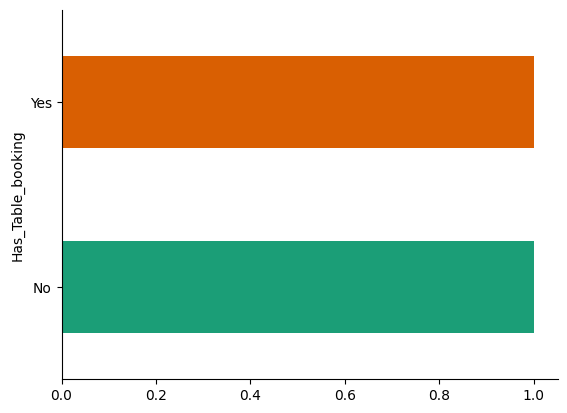

In [62]:
from matplotlib import pyplot as plt
import seaborn as sns
booking_counts.groupby('Has_Table_booking').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [64]:
delivery_df = fact_main[fact_main["Has_Online_delivery"].notna()]

In [66]:
delivery_counts = (
    delivery_df
    .groupby("Has_Online_delivery")
    .agg(Restaurant_Count=("RestaurantID", "count"))
    .reset_index()
)

In [67]:
total_restaurants = delivery_counts["Restaurant_Count"].sum()

delivery_counts["Percentage"] = (
    delivery_counts["Restaurant_Count"] / total_restaurants * 100
).round(2)

In [68]:
delivery_counts

,Has_Online_delivery,Restaurant_Count,Percentage
0,No,7100,74.34
1,Yes,2451,25.66


from matplotlib import pyplot as plt
delivery_counts['Restaurant_Count'].plot(kind='hist', bins=20, title='Restaurant_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
delivery_counts['Percentage'].plot(kind='hist', bins=20, title='Percentage')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
delivery_counts.groupby('Has_Online_delivery').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
delivery_counts.plot(kind='scatter', x='Restaurant_Count', y='Percentage', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
delivery_counts['Percentage'].plot(kind='line', figsize=(8, 4), title='Percentage')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(delivery_counts['Has_Online_delivery'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(delivery_counts, x='Restaurant_Count', y='Has_Online_delivery', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(delivery_counts['Has_Online_delivery'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(delivery_counts, x='Percentage', y='Has_Online_delivery', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

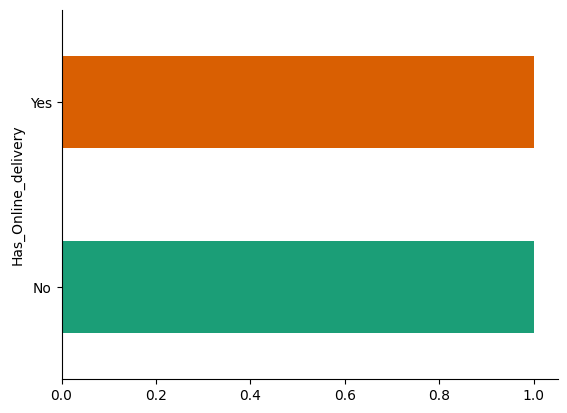

In [69]:
from matplotlib import pyplot as plt
import seaborn as sns
delivery_counts.groupby('Has_Online_delivery').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

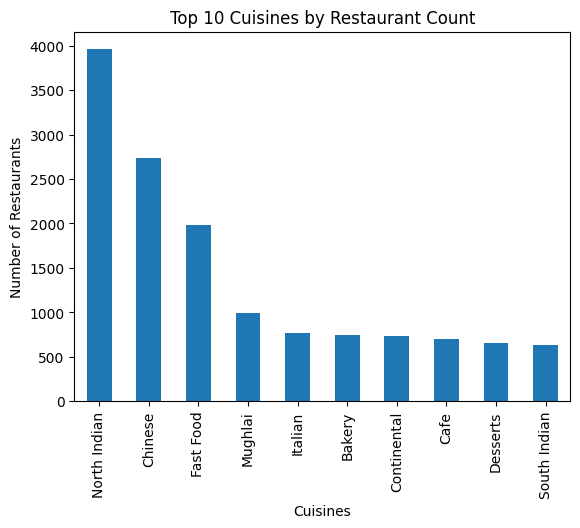

In [71]:
top_cuisines = (
    final_df["Cuisines"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

top_cuisines.plot(kind="bar", title="Top 10 Cuisines by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.show()

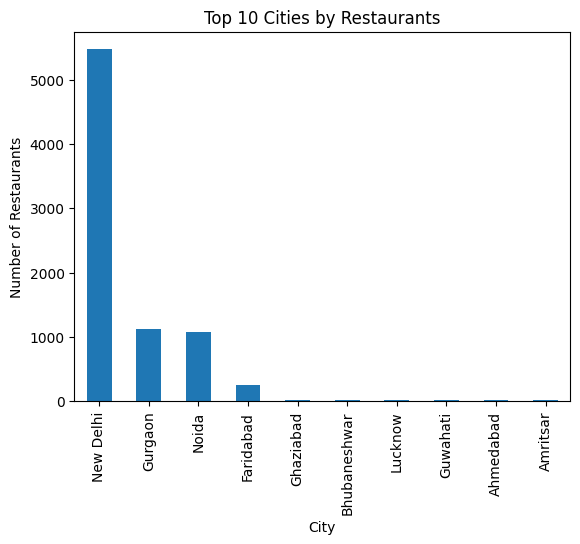

In [73]:
top_cities = (
    final_df.groupby("City")
      .agg(Restaurant_Count=("RestaurantID", "count"))
      .sort_values("Restaurant_Count", ascending=False)
      .head(10)
)

top_cities.plot(kind="bar", title="Top 10 Cities by Restaurants", legend=False)
plt.ylabel("Number of Restaurants")
plt.show()

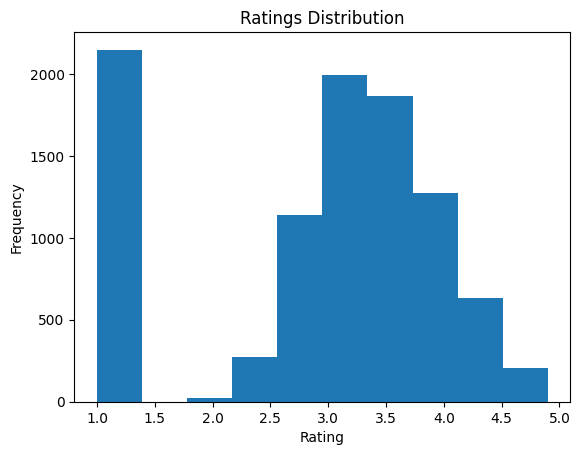

In [75]:
ratings_df = final_df[final_df["Rating"] > 0]

ratings_df["Rating"].plot(
    kind="hist",
    bins=10,
    title="Ratings Distribution"
)
plt.xlabel("Rating")
plt.show()

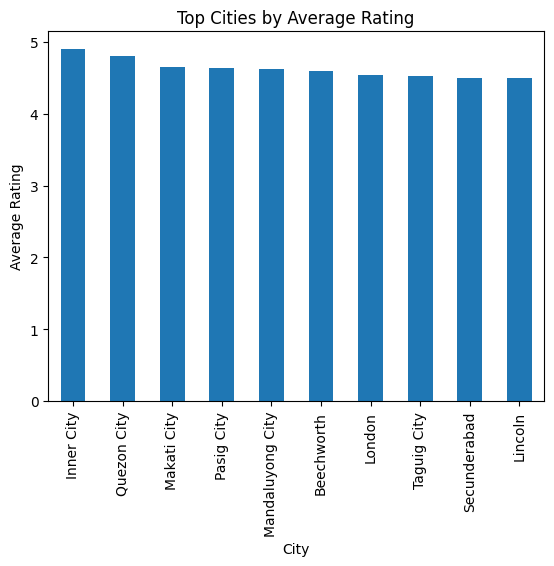

In [77]:
avg_rating_city = (
    ratings_df.groupby("City")
    .agg(Avg_Rating=("Rating", "mean"))
    .sort_values("Avg_Rating", ascending=False)
    .head(10)
)

avg_rating_city.plot(kind="bar", title="Top Cities by Average Rating", legend=False)
plt.ylabel("Average Rating")
plt.show()

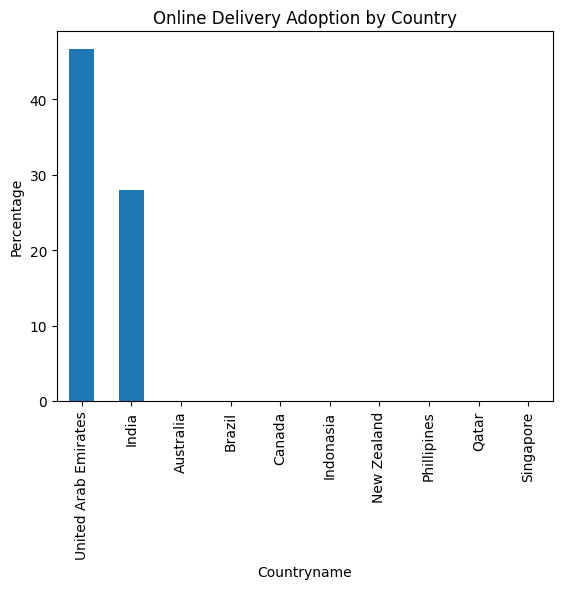

In [81]:
delivery_country = (
    final_df.groupby(["Countryname", "Has_Online_delivery"])
    .size()
    .unstack()
)

delivery_country["Online_Delivery_%"] = (
    delivery_country["Yes"] /
    (delivery_country["Yes"] + delivery_country["No"]) * 100
)

(delivery_country["Online_Delivery_%"]
.sort_values(ascending=False)
.head(10)
.plot(
    kind="bar",
    title="Online Delivery Adoption by Country"
))
plt.ylabel("Percentage")
plt.show()

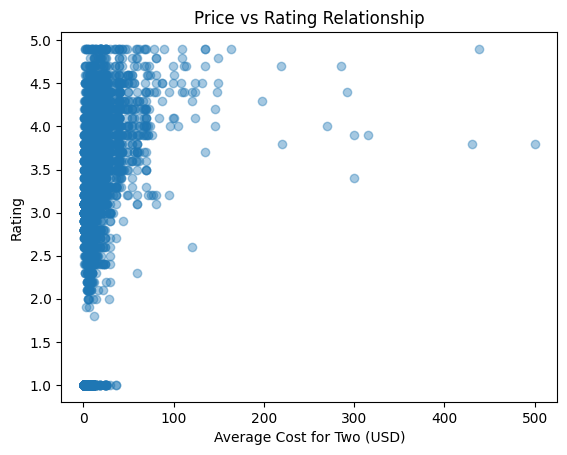

In [85]:
price_rating = final_df[
    (final_df["Average_Cost_for_two_USD"] > 0) & (final_df["Rating"] > 0)
]

plt.scatter(
    price_rating["Average_Cost_for_two_USD"],
    price_rating["Rating"],
    alpha=0.4
)
plt.title("Price vs Rating Relationship")
plt.xlabel("Average Cost for Two (USD)")
plt.ylabel("Rating")
plt.show()

In [89]:
total_restaurants = final_df["RestaurantID"].nunique()
avg_rating = ratings_df["Rating"].mean()
online_delivery_pct = (
    (final_df["Has_Online_delivery"] == "Yes").mean() * 100
)
table_booking_pct = (
    (final_df["Has_Table_booking"] == "Yes").mean() * 100
)

print("------ ZOMATO DASHBOARD KPIs ------")
print(f"Total Restaurants: {total_restaurants}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Online Delivery %: {online_delivery_pct:.2f}%")
print(f"Table Booking %: {table_booking_pct:.2f}%")

------ ZOMATO DASHBOARD KPIs ------
Total Restaurants: 9551
Average Rating: 2.89
Online Delivery %: 25.66%
Table Booking %: 12.12%
